## Lista 05 - SVM e comitês de modelos

### Imports

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import UndefinedMetricWarning

#### Funções Auxiliares

In [2]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] 

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n--- Métricas: {name} ---")
    print(f"Acurácia: {acc:.4f}")
    print(f"Revocação: {rec:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"F1-score: {f1:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    return fpr, tpr, roc_auc, precision, recall, pr_auc

### Questão 01 

In [3]:
data = np.loadtxt('californiabin.csv', delimiter=',')

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

X = data[:, :8]
y = data[:, 8]

### Item a)

In [4]:
# divisão dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

#### SVM

In [5]:
c_values = [2.0**i for i in range(-5, 16, 2)]
gamma_values = [2.0**i for i in range(-15, 2, 2)] + [2.0**2, 2.0**3]

svm_param_grid = { 'C': c_values, 'gamma': gamma_values }

svm_model = SVC(kernel='rbf', probability=True, random_state=42)

print("Iniciando Grid Search para SVM")
svm_grid = GridSearchCV(svm_model, svm_param_grid, cv=10, scoring='accuracy', n_jobs=-1, refit=True)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

Iniciando Grid Search para SVM


#### Random Forest

In [6]:
rf_param_grid = {
    'n_estimators': list(range(10, 210, 10)),
    'max_depth': [4, 6, 8, 10, None]
}

rf_model = RandomForestClassifier(random_state=42)

print("Iniciando Grid Search para Random Forest")
rf_grid = GridSearchCV(rf_model, rf_param_grid, cv=10, scoring='accuracy', n_jobs=-1, refit=True)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_


Iniciando Grid Search para Random Forest


#### item b)

In [7]:
print("\n" + "-"*40)
print(" Hiperparâmetros selecionados")
print("-"*40)
print(f"SVM: {svm_grid.best_params_}")
print(f"Random Forest: {rf_grid.best_params_}")

print("\n" + "-"*40)
print("Métricas nos dados de teste")
print("-"*40)
svm_fpr, svm_tpr, svm_roc_auc, svm_prec, svm_rec, svm_pr_auc = evaluate_model(best_svm, "SVM", X_test, y_test)
rf_fpr, rf_tpr, rf_roc_auc, rf_prec, rf_rec, rf_pr_auc = evaluate_model(best_rf, "Random Forest", X_test, y_test)


----------------------------------------
 Hiperparâmetros selecionados
----------------------------------------
SVM: {'C': 32768.0, 'gamma': 3.0517578125e-05}
Random Forest: {'max_depth': None, 'n_estimators': 70}

----------------------------------------
Métricas nos dados de teste
----------------------------------------

--- Métricas: SVM ---
Acurácia: 0.7800
Revocação: 0.7664
Precisão: 0.8119
F1-score: 0.7885

--- Métricas: Random Forest ---
Acurácia: 0.8325
Revocação: 0.8131
Precisão: 0.8657
F1-score: 0.8386


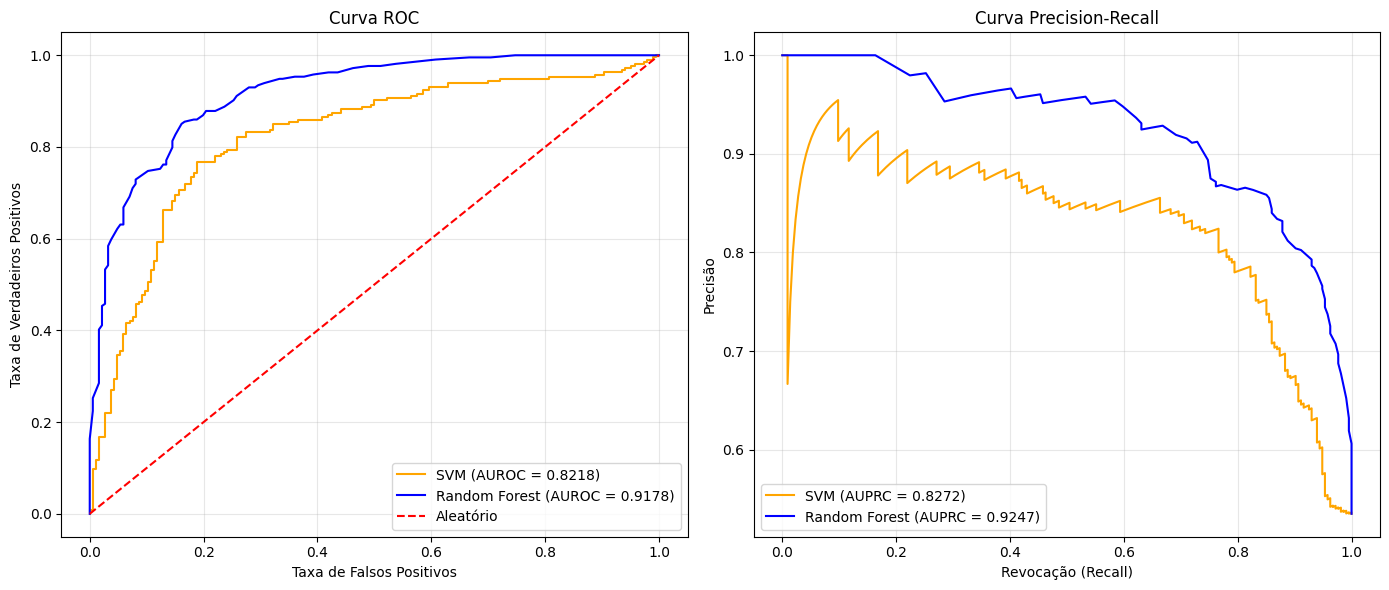

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(svm_fpr, svm_tpr, color='orange', label=f'SVM (AUROC = {svm_roc_auc:.4f})')
ax1.plot(rf_fpr, rf_tpr, color='blue', label=f'Random Forest (AUROC = {rf_roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='red', linestyle='--', label='Aleatório')
ax1.set_xlabel('Taxa de Falsos Positivos')
ax1.set_ylabel('Taxa de Verdadeiros Positivos')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

ax2.plot(svm_rec, svm_prec, color='orange', label=f'SVM (AUPRC = {svm_pr_auc:.4f})')
ax2.plot(rf_rec, rf_prec, color='blue', label=f'Random Forest (AUPRC = {rf_pr_auc:.4f})')
ax2.set_xlabel('Revocação (Recall)')
ax2.set_ylabel('Precisão')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()